# LightGBM - Global Interpretation
- Notebook completed by Adam Lang
- This is from the train in data course by Soledad Galli, PhD, which I highly recommend taking to enhance your ML explainability skills.
- Date: 8-24-2026

## Imports

In [1]:
## imports
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

## sklearn imports
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split ## train-test split

## LightGBM model
from lightgbm import LGBMRegressor

## Load Dataset

In [2]:
## load california housing price prediction dataset from sklearn
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X = X.drop(columns=["Latitude", "Longitude"]) ## drop features we dont need

## view top 5 rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467


## Visualize Dataset

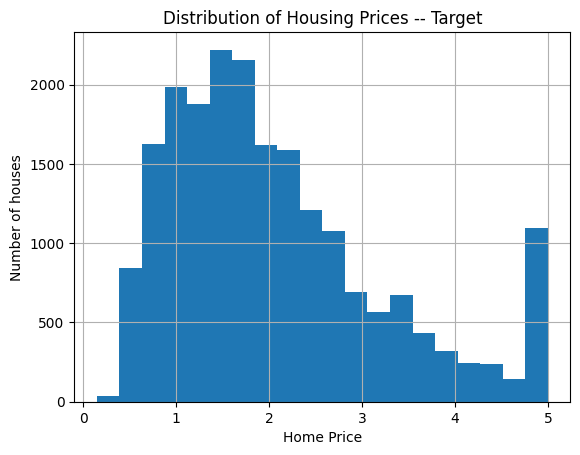

In [3]:
## view target distribution
y.hist(bins=20)
plt.xlabel("Home Price")
plt.ylabel("Number of houses")
plt.title("Distribution of Housing Prices -- Target")
plt.show();

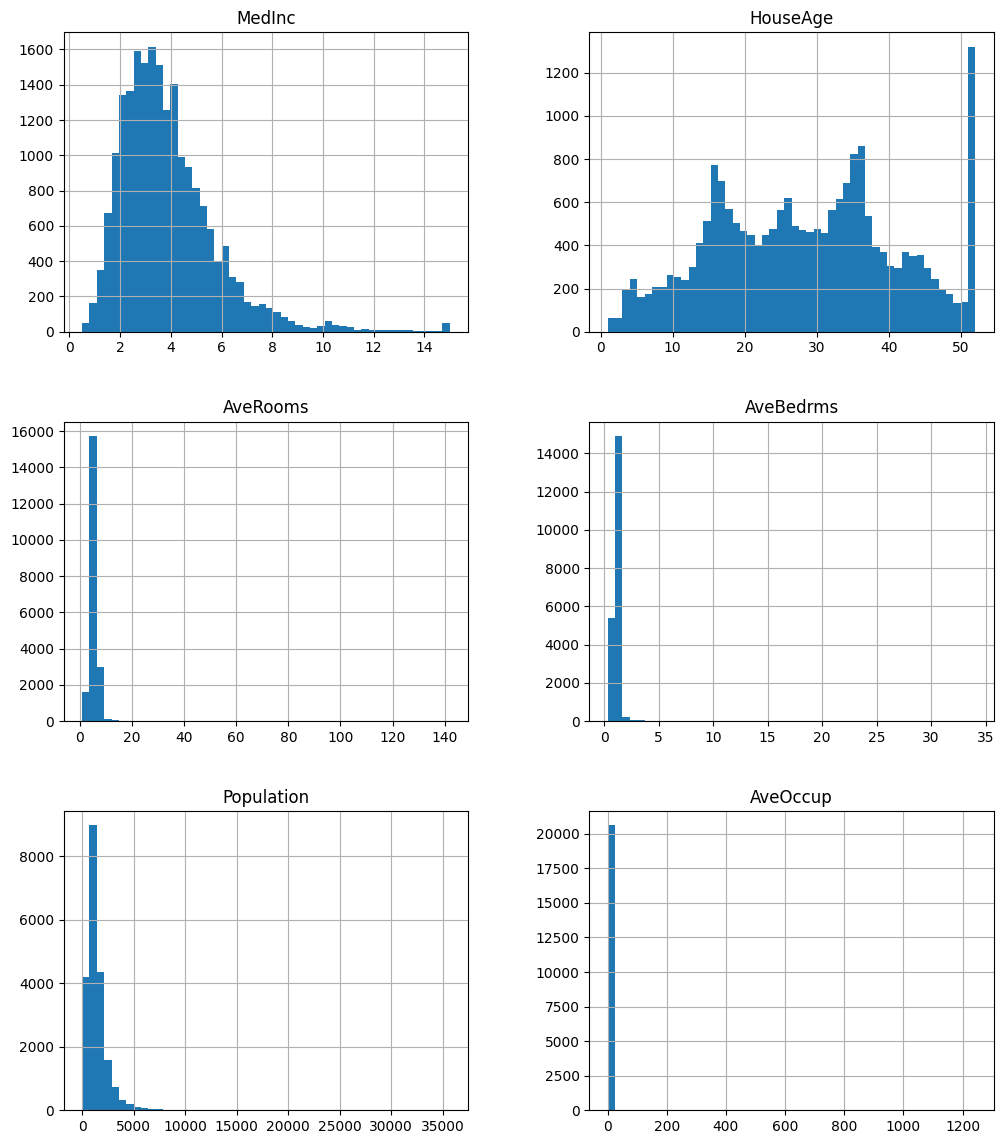

In [4]:
## display variables distribution
X.hist(bins=50, figsize=(12,14))
plt.show();

## Train-Test-Split

In [5]:
## train-test split for model train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


## shape
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (14448, 6)
X_test shape: (6192, 6)


## LightGBM - Fit Model

In [6]:
## fit model
gbm = LGBMRegressor(
    importance_type="gain", ## gain = sum of squares
    n_estimators=50,
    max_depth=3,
    random_state=3,
)
## fit to data
gbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001219 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 14448, number of used features: 6
[LightGBM] [Info] Start training from score 2.069240
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

LGBMRegressor(importance_type='gain', max_depth=3, n_estimators=50,
              random_state=3)

In [7]:
## R2 in train set
gbm.score(X_train, y_train)

0.6901304716530848

In [8]:
## R2 in test set
gbm.score(X_test, y_test)

0.6670080476943161

## Summary
- Similar to other boosting models we can see here than a little over 60% of the variability is explained by the model in the target variable.

## Feature Importance -- Global Explanations

In [9]:
## gbm importance
global_exp = pd.Series(gbm.feature_importances_,
                       index=X_train.columns.to_list()) ## pass as list

global_exp

,0
MedInc,51489.039100
HouseAge,4684.841561
AveRooms,2748.785133
AveBedrms,551.371295
Population,342.814941
AveOccup,10489.028642


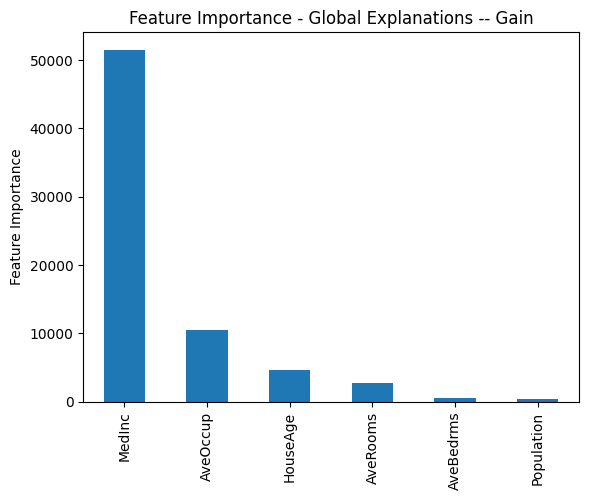

In [10]:
## plot global exp
global_exp.sort_values(ascending=False).plot.bar()
plt.ylabel("Feature Importance")
plt.title("Feature Importance - Global Explanations -- Gain")
plt.show();

## Summary
- We can see Median income is significantly more important here.

### LightGBM with `split` feature imortance
- Split feature importance measures the total number of times a feature is used to split the data across all decision trees in the model.
- It is the default metric used by LightGBM when you call `.feature_importances_` or plot the importance.
- Frequency-Based:
  - It simply counts occurrences.
  - Every time a tree node uses the feature to divide data, its score increases by one.

- No Quality Weighting:
  - It treats every split equally.
  - A split at the very top of a tree (which affects all data) adds the same +1 as a split at a bottom leaf node (which affects few samples).


- Split importance has a well-known limitation.

  - Features with many unique values (like IDs, dates, or fine-grained numerical variables) naturally offer more opportunities for splitting.
  - Consequently, LightGBM will often split on them repeatedly, artificially inflating their split importance score even if they don't actually improve the model's accuracy very much

[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 14448, number of used features: 6
[LightGBM] [Info] Start training from score 2.069240
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

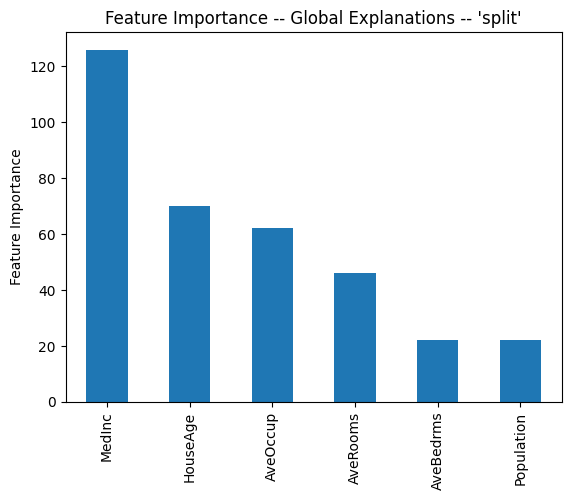

In [13]:
## fit with `split` feature importance
gbm = LGBMRegressor(
    importance_type="split", ## num of nodes that use specific feature
    n_estimators=50,
    max_depth=3,
    force_col_wise=True,
    random_state=3,
)
gbm.fit(X_train, y_train)

## plot feature importance for `split`
global_exp = pd.Series(gbm.feature_importances_, index=X_train.columns.to_list())
global_exp.sort_values(ascending=False).plot.bar()
plt.ylabel("Feature Importance")
plt.title("Feature Importance -- Global Explanations -- 'split'")
plt.show();

## Summary
- The different importance metrics show us different aspects of the ensemble.

1. Gain -- returns very similar importance values to those that sklearn will.

2. Split -- number of times a feature was chosen by a node (gives alternative view of feature of ensemble)